# Analisis de Sentimiento con TextBlob

### De un dataset limpio a una etiqueta por tweet

En el notebook anterior dejamos el dataset de tweets sobre aerolineas ya limpio, con dos versiones de texto: `texto_sentimiento` (menciones y links afuera, pero la oracion intacta) y `texto_topicos` (lematizado, sin stopwords). Hoy usamos la primera para clasificar cada tweet como **Positivo**, **Neutral** o **Negativo**.

### Un enfoque distinto al que ya vimos

Hace dos notebooks entrenamos un clasificador de sentimiento nosotros mismos: una `Embedding` + `GRU` que aprendia, a partir de miles de ejemplos etiquetados, a distinguir review positivas de negativas. Hoy vamos a usar un enfoque totalmente distinto: **TextBlob**, una libreria que no aprende de datos etiquetados. En cambio, usa un diccionario interno donde cada palabra tiene una polaridad asignada de antemano (por ejemplo, "great" suma, "terrible" resta), y calcula un puntaje combinando las palabras de la oracion.

Es un enfoque mucho mas simple y rapido de poner en marcha (no hace falta entrenar nada), pero como vamos a ver al final del notebook, tiene sus propias limitaciones.

## 0. Preparando el entorno

In [ ]:
!pip install textblob
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob, Word

## 1. Retomando el dataset limpio

Cargamos el csv que guardamos al final del notebook anterior.

In [ ]:
df = pd.read_csv("feedback_aerolineas_limpio.csv")
df.head()

,id,sentimiento_original,razon_negativa,aerolinea,texto,texto_sentimiento,texto_topicos
0,570306133677760513,neutral,NaN,Virgin America,@VirginAmerica What @dhepburn said.,What said.,say
1,570301130888122368,positive,NaN,Virgin America,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...,plus add commercial experience tacky
2,570301083672813571,neutral,NaN,Virgin America,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take ano...,today mean need trip
3,570301031407624196,negative,Bad Flight,Virgin America,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent...",aggressive blast obnoxious entertainment guest...
4,570300817074462722,negative,Can't Tell,Virgin America,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it,big bad thing


## 2. Como funciona TextBlob

In [ ]:
oracion_positiva = "The crew was amazing and super helpful during the whole flight."
oracion_negativa = "This was the worst flight experience I have ever had."

# # Separamos el texto en palabras (tokenizacion)
blob = TextBlob(oracion_positiva)
print("palabras:", blob.words)

# Separamos el texto en oraciones
print("Oraciones:", blob.sentences)


palabras: ['The', 'crew', 'was', 'amazing', 'and', 'super', 'helpful', 'during', 'the', 'whole', 'flight']
Oraciones: [Sentence("The crew was amazing and super helpful during the whole flight.")]


**TextBlob puede quantificar la polaridad**

`TextBlob(texto).sentiment` devuelve dos numeros:

- **polarity**: entre -1 (muy negativo) y 1 (muy positivo).
- **subjectivity**: entre 0 (muy objetivo, factual) y 1 (muy subjetivo, opinion).

Probemos con un par de oraciones bien contrastantes antes de aplicarlo a tweets reales.

In [ ]:
# Obtenemos la polaridad:
# -1 = muy negativo
#  0 = neutral
# +1 = muy positivo

print("Positiva:", TextBlob(oracion_positiva).sentiment)
print("Negativa:", TextBlob(oracion_negativa).sentiment)

Positiva: Sentiment(polarity=0.37777777777777777, subjectivity=0.6555555555555556)
Negativa: Sentiment(polarity=-1.0, subjectivity=1.0)


In [ ]:
# una comparacion para ver cómo la polaridad cambia según el texto
textos = [
    "I love this airline!",
    "The flight was okay.",
    "This was a terrible experience."
]

for texto in textos:

    blob = TextBlob(texto)

    print(
        f"{texto:<40} "
        f"polaridad={blob.sentiment.polarity:.2f}"
    )

I love this airline!                     polaridad=0.62
The flight was okay.                     polaridad=0.50
This was a terrible experience.          polaridad=-1.00


## 3. Clasificando cada tweet

Vamos a convertir ese puntaje continuo (`polarity`) en tres categorias, usando dos umbrales: por encima de 0.1 consideramos que el tweet es positivo, por debajo de -0.1 lo consideramos negativo, y en el medio queda como neutral.

In [ ]:
def clasificar_sentimiento(texto):
    polaridad = TextBlob(texto).sentiment.polarity
    if polaridad > 0.1:
        return "Positivo"
    elif polaridad < -0.1:
        return "Negativo"
    else:
        return "Neutral"


df["sentimiento"] = df["texto_sentimiento"].apply(clasificar_sentimiento)
df[["texto_sentimiento", "sentimiento"]].head(10)

,texto_sentimiento,sentimiento
0,What said.,Neutral
1,plus you've added commercials to the experienc...,Neutral
2,I didn't today... Must mean I need to take ano...,Negativo
3,"it's really aggressive to blast obnoxious ""ent...",Neutral
4,and it's a really big bad thing about it,Negativo
5,seriously would pay $30 a flight for seats tha...,Negativo
6,"yes, nearly every time I fly VX this “ear worm...",Positivo
7,Really missed a prime opportunity for Men With...,Positivo
8,"Well, I didn't…but NOW I DO! :-D",Positivo
9,"it was amazing, and arrived an hour early. You...",Positivo


## 4. Visualizando la salud del feedback

Grafiquemos la distribucion porcentual de las tres categorias, para tener una foto general de como viene el feedback de los clientes.

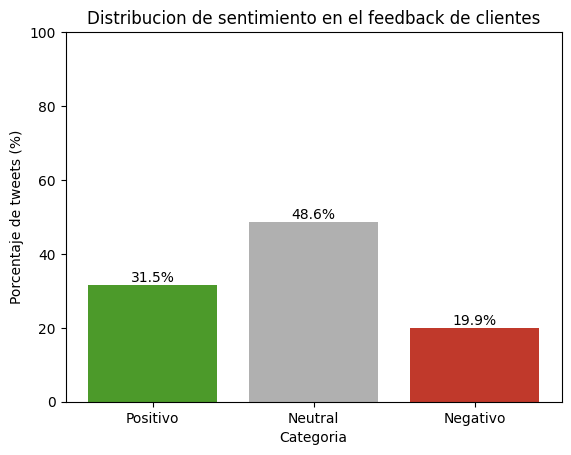

In [ ]:
distribucion = df["sentimiento"].value_counts(normalize=True) * 100
distribucion = distribucion.reindex(["Positivo", "Neutral", "Negativo"])

plt.bar(distribucion.index, distribucion.values, color=["#4C9A2A", "#B0B0B0", "#C0392B"])
plt.title("Distribucion de sentimiento en el feedback de clientes")
plt.xlabel("Categoria")
plt.ylabel("Porcentaje de tweets (%)")
plt.ylim(0, 100)
for i, valor in enumerate(distribucion.values):
    plt.text(i, valor + 1, f"{valor:.1f}%", ha="center")
plt.show()

## 5. Comparando contra la etiqueta original

Este dataset tiene algo que casi nunca vamos a tener en la vida real: la etiqueta "correcta" (`sentimiento_original`), puesta a mano por personas cuando se armo el dataset. Aprovechemos eso para ver que tan de acuerdo esta TextBlob con esas etiquetas.

In [ ]:
pd.crosstab(df["sentimiento_original"], df["sentimiento"])

sentimiento,Negativo,Neutral,Positivo
sentimiento_original,,,
negative,2623,4522,2033
neutral,224,2009,866
positive,63,582,1718


Es esperable que no coincidan siempre. Fijate en particular cuantos tweets etiquetados como "negative" por las personas terminan clasificados como "Neutral" o incluso "Positivo" por TextBlob. Eso nos lleva al proximo punto.

691 tweets que los humanos etiquetaron como negativos también fueron clasificados como negativos por TextBlob.  
55 tweets que los humanos etiquetaron como neutrales fueron clasificados como negativos por TextBlob.

## 6. Los limites de este enfoque

TextBlob no entiende el contexto, ni el sarcasmo, ni el dominio especifico del texto que esta leyendo: solo suma y resta polaridades de palabras individuales. Un ejemplo real, tomado de este mismo dataset, etiquetado como negativo por una persona:

> "called your service line and was hung up on. This is awesome. #sarcasm"

La persona que escribio el tweet incluso puso el hashtag `#sarcasm`. Pero para TextBlob, la palabra "awesome" pesa mucho, y el resultado es una polaridad casi maxima (positiva).

Verifiquemoslo nosotros mismos.

In [ ]:
tweet_sarcastico = "called your service line and was hung up on. What a great help! #sarcasm"
print(TextBlob(tweet_sarcastico).sentiment)

Sentiment(polarity=1.0, subjectivity=1.0)


Este mismo tipo de limitacion aparece con cualquier herramienta de sentimiento.  
Por ejemplo, un modelo mucho mas sofisticado que TextBlob clasificaba "I am from Iraq" como muy negativo simplemente por asociaciones aprendidas de sus datos de entrenamiento. Ninguna herramienta de sentimiento es neutral ni perfecta: siempre conviene revisar casos puntuales antes de confiar ciegamente en el numero que devuelve.

## 7. Guardando los resultados

Guardamos el dataset con la columna `sentimiento` agregada: la vamos a necesitar en el proximo notebook para quedarnos solo con los tweets negativos.

In [ ]:
df.to_csv("feedback_aerolineas_sentimiento.csv", index=False)
print("Guardado. Filas:", len(df))

Guardado. Filas: 14640


## Resumen

- **TextBlob** clasifica sentimiento usando un diccionario de polaridades por palabra, sin necesidad de entrenar nada, a diferencia del clasificador `Embedding` + `GRU` que armamos antes.
- Convertimos un puntaje continuo (`polarity`) en categorias usando umbrales.
- Comparar contra una etiqueta "verdadera" nos permite medir que tan bien funciona el enfoque, y donde falla.
- Ninguna herramienta de sentimiento es perfecta: el sarcasmo y el contexto especifico del dominio son puntos ciegos comunes, tanto en herramientas simples como en modelos mas sofisticados.

En el proximo notebook usamos este dataset ya clasificado para buscar comentarios similares entre si, y para descubrir automaticamente los principales temas de queja dentro de los tweets negativos.